In [1]:
import sys
sys.path.append('../')

In [2]:
import Hamiltonian as ham
import scipy.sparse as sp
import numpy as np
from matplotlib import pyplot as plt
import Evolution as evol

In [3]:
from qrisp.operators import X, Y, Z

def TFIM_qr(J,h,n_qubits):
    H = 0
    for i in range(n_qubits):
        i_next = (i+1)%n_qubits
        H += J*Z(i)*Z(i_next) + h*X(i)
    return H

/home/luca/Documents/QITE-UV/Qite/lib/python3.12/site-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.1 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [4]:
N=3
J=0.5
h=1.0
H = TFIM_qr(J,h,N)

def exp_H(qv,t):
    # Applies 5 Trotter steps of the Hamiltonian evolution
    H.trotterization(method='commuting')(qv, t, 1)

def U_0(qv):
    pass

In [5]:
import numpy as np
import sympy as sp
from qrisp import QuantumVariable
from qrisp.algorithms.qite import QITE

steps = 6
s_values = np.linspace(.01, .3, 10) # Evolution times to test

theta = sp.Symbol('theta')
optimal_s = [theta]
optimal_energies = [H.expectation_value(lambda : QuantumVariable(N))()]

for k in range(1, steps + 1):
    # 1. Initialize a QuantumVariable with N qubits
    qv = QuantumVariable(N)
    
    # 2. Apply k steps of QITE 
    # Notice we pass `optimal_s` which contains our parameterized symbolic `theta`
    QITE(qarg=qv, U_0=U_0, exp_H=exp_H, s=optimal_s, k=k)
    
    # Compile the circuit once to speed up the optimization loop
    qc = qv.qs.compile()

    # 3. Find the optimal evolution time `s` for this step
    energies = [
        H.expectation_value(
            qv, 
            subs_dic={theta: s_}, # Substitute theta with the actual time
            precompiled_qc=qc, 
            diagonalisation_method='commuting'
        )()
        for s_ in s_values
    ]
    
    # 4. Get the time that resulted in the lowest energy
    index = np.argmin(energies)
    s_min = s_values[index]

    # Save the optimal time for the next step's sequence
    optimal_s.insert(-1, s_min)
    optimal_energies.append(energies[index])
    
    print(f"Step {k}: Lowest Energy = {energies[index]:.4f}")

Simulating 3 qubits.. |                                                 | [  0%]

Step 1: Lowest Energy = 0.9611                                                  
Step 2: Lowest Energy = 0.1720                                                  
Step 3: Lowest Energy = -0.7229                                                 
Step 4: Lowest Energy = -1.5644                                                 
Step 5: Lowest Energy = -2.2716                                                 
Step 6: Lowest Energy = -2.7374                                                 


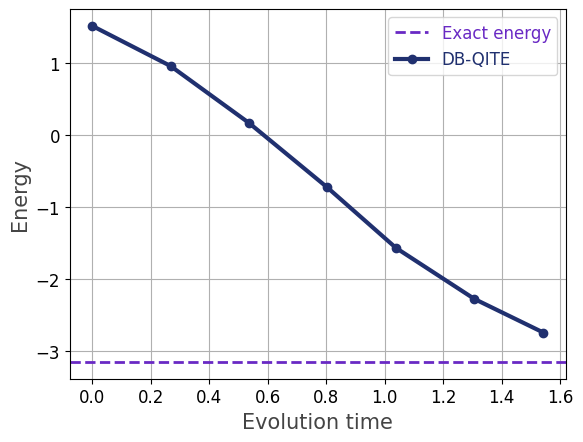

In [6]:
import matplotlib.pyplot as plt

evolution_times = [sum(optimal_s[i] for i in range(k)) for k in range(steps+1)]

plt.xlabel('Evolution time', fontsize=15, color='#444444')
plt.ylabel('Energy', fontsize=15, color='#444444')
plt.axhline(y=H.ground_state_energy(), color='#6929C4', linestyle='--', linewidth=2, label='Exact energy')
plt.plot(evolution_times, optimal_energies, c='#20306f', marker="o", linestyle='solid', linewidth=3, zorder=3, label='DB-QITE')
plt.legend(fontsize=12, labelcolor='linecolor')
plt.tick_params(axis='both', labelsize=12)
plt.grid()
plt.show()